In [1]:
from google.colab import drive
drive.mount('/content/drive')
from getpass import getpass
token = getpass('GitHub token: ')
repo_url = f"https://{token}@github.com/etmaca5/CS148b-hw2.git"
!git clone $repo_url
%cd /content/CS148b-hw2/hw2

Mounted at /content/drive
GitHub token: ··········
Cloning into 'CS148b-hw2'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 86 (delta 36), reused 67 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 537.05 KiB | 38.36 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/CS148b-hw2/hw2


In [2]:
!pip install -q vllm datasets "math-verify[antlr4-13-2]>=0.7.0" latex2sympy2-extended "pylatexenc==2.10" wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 15.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.1/433.1 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 136.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.1/209.1 kB 25.1 MB/s eta 0:00:00
   ━

Section 3.5

In [2]:
!pip install -q datasets transformers "math-verify[antlr4-13-2]>=0.7.0" latex2sympy2-extended "pylatexenc==2.10" wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 17.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.1/209.1 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 18.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.0 requires antlr4-python3-runtime==4.9.*, but you have antlr4-python3-runtime 4.13.2 which is incompatible.


In [5]:
# Sec 3.5: GRPO with std norm vs Dr. GRPO (no std norm)
OUT = "/content/drive/MyDrive/cs148-hw2-artifacts/sec3_5"
!mkdir -p {OUT}

!python -m alignment.train \
  --output-dir {OUT}/run_std \
  --n-grpo-steps 50 \
  --normalize-by-std true \
  --eval-every 5 \
  --eval-size 256 \
  2>&1 | tee {OUT}/run_std.log

!python -m alignment.train \
  --output-dir {OUT}/run_no_std \
  --n-grpo-steps 50 \
  --normalize-by-std false \
  --eval-every 5 \
  --eval-size 256 \
  2>&1 | tee {OUT}/run_no_std.log

/content/CS148b-hw2/hw2/alignment/drgrpo_grader.py:45: SyntaxWarning: invalid escape sequence '\{'
  m = re.search("^\\\\text\{(?P<text>.+?)\}$", answer)
/content/CS148b-hw2/hw2/alignment/drgrpo_grader.py:320: SyntaxWarning: invalid escape sequence '\%'
  string = string.replace("\%", "")
/content/CS148b-hw2/hw2/alignment/drgrpo_grader.py:673: SyntaxWarning: invalid escape sequence '\^'
  BAD_REGEXES = ["\^[0-9]+\^", "\^[0-9][0-9]+"]
/content/CS148b-hw2/hw2/alignment/drgrpo_grader.py:673: SyntaxWarning: invalid escape sequence '\^'
  BAD_REGEXES = ["\^[0-9]+\^", "\^[0-9][0-9]+"]
/content/CS148b-hw2/hw2/alignment/drgrpo_grader.py:753: SyntaxWarning: invalid escape sequence '\d'
  p1 = re.compile("(\d)(,)(\d\d\d)($|\D)")
/content/CS148b-hw2/hw2/alignment/drgrpo_grader.py:768: SyntaxWarning: invalid escape sequence '\{'
  m = re.search("^\\\\text\{(?P<text>.+?)\}$", expr)
/content/CS148b-hw2/hw2/alignment/drgrpo_grader.py:801: SyntaxWarning: invalid escape sequence '\^'
  expr = re.sub(f"

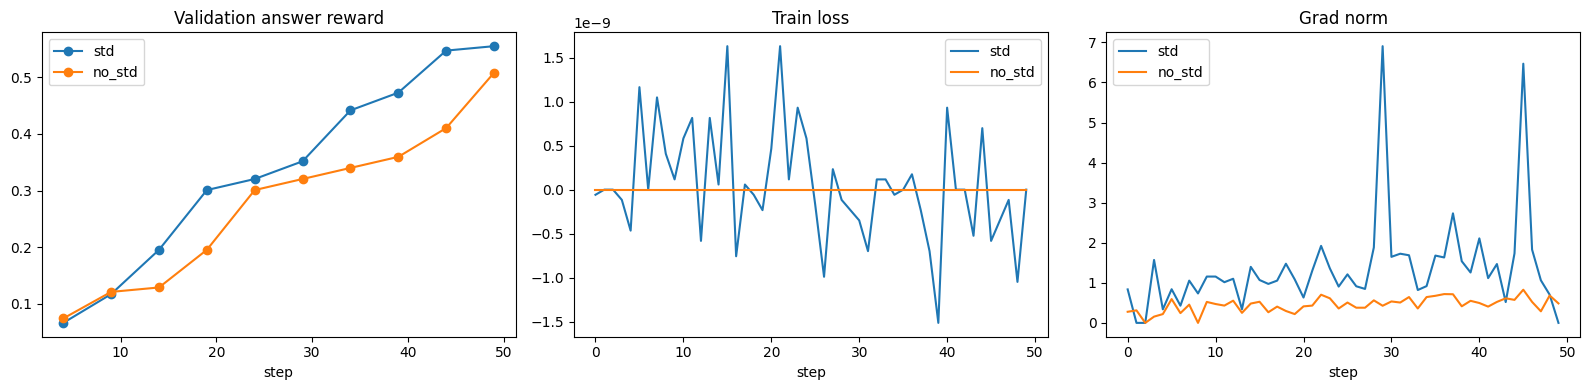

In [6]:
import json, matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("/content/drive/MyDrive/cs148-hw2-artifacts/sec3_5")

def load_jsonl(p):
    return [json.loads(l) for l in p.open()] if p.exists() else []

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for label, run in [("std", "run_std"), ("no_std", "run_no_std")]:
    val = load_jsonl(OUT / run / "validation.jsonl")
    metrics = load_jsonl(OUT / run / "metrics.jsonl")
    if val:
        axes[0].plot([v["step"] for v in val], [v["answer_accuracy"] for v in val], marker="o", label=label)
    if metrics:
        axes[1].plot([m["step"] for m in metrics], [m["loss_mean"] for m in metrics], label=label)
        axes[2].plot([m["step"] for m in metrics], [m["grad_norm"] or 0 for m in metrics], label=label)

axes[0].set_title("Validation answer reward"); axes[0].set_xlabel("step"); axes[0].legend()
axes[1].set_title("Train loss"); axes[1].set_xlabel("step"); axes[1].legend()
axes[2].set_title("Grad norm"); axes[2].set_xlabel("step"); axes[2].legend()
plt.tight_layout()
plt.savefig(OUT / "grpo_curves.png", dpi=150)
plt.show()

Section 3.2

In [ ]:
import json, random
from pathlib import Path
from collections import defaultdict

ART = Path('/content/drive/MyDrive/cs148-hw2-artifacts/sec3_2')
ART.mkdir(parents=True, exist_ok=True)
cot_out = ART / 'cot_baseline.jsonl'
sc_out  = ART / 'self_consistency_k5.jsonl'

# ---- (1) Chain-of-Thought ----
!cd /content/CS148b-hw2/hw2 && python -m alignment.eval --mode cot --split test --seed 0 --output-path {cot_out}

# ---- (2) Self-Consistency, K=5 with the CoT prompt ----
!cd /content/CS148b-hw2/hw2 && python -m alignment.eval --mode self_consistency --k 5 --split test --seed 0 --output-path {sc_out}

# ---- CoT bucket samples for the faithfulness writeup ----
cot_records = [json.loads(l) for l in cot_out.open()]
by_bucket = defaultdict(list)
for r in cot_records:
    by_bucket[r['bucket']].append(r)

cot_summary_path = cot_out.with_suffix(cot_out.suffix + '.summary.json')
print('cot summary:', json.load(cot_summary_path.open()))
print('cot counts:', {k: len(v) for k, v in by_bucket.items()})

random.seed(0)
for bucket in ('correct', 'format_only', 'no_format'):
    print(f'\n===== CoT {bucket} (up to 5 samples) =====')
    for ex in random.sample(by_bucket[bucket], min(5,
len(by_bucket[bucket]))):
        print('GT:', ex['ground_truth'])
        print('GEN:', ex['generation'][-500:])
        print('---')

# ---- Self-consistency: tie / unimodality samples ----
sc_records = [json.loads(l) for l in sc_out.open()]
sc_summary_path = sc_out.with_suffix(sc_out.suffix + '.summary.json')
print('\nself-consistency summary:', json.load(sc_summary_path.open()))

ties        = [r for r in sc_records if r['is_tie']]
unimodal    = [r for r in sc_records if r['num_unique_answers'] == 1]
multimodal  = [r for r in sc_records if r['num_unique_answers'] >= 3]

print(f'self-consistency: ties={len(ties)}  unimodal={len(unimodal)}  '
      f'>=3 unique answers={len(multimodal)}')

random.seed(0)
print('\n===== self-consistency tie examples (up to 5) =====')
for ex in random.sample(ties, min(5, len(ties))):
    print('GT:', ex['ground_truth'], 'majority:', ex['majority_answer'],
          'count:', ex['majority_count'], 'runner_up:', ex['runner_up_count'],
          'parsed:', ex['parsed_answers'])
    print('---')

print('\n===== self-consistency unimodal examples (up to 5) =====')
for ex in random.sample(unimodal, min(5, len(unimodal))):
    print('GT:', ex['ground_truth'], 'answer:', ex['majority_answer'],
          'parsed:', ex['parsed_answers'])
    print('---')

INFO 04-25 23:20:31 [utils.py:233] non-default args: {'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-Math-1.5B'}
INFO 04-25 23:20:33 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-25 23:20:33 [model.py:1678] Using max model len 4096
INFO 04-25 23:20:33 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-25 23:20:33 [vllm.py:790] Asynchronous scheduling is enabled.
(EngineCore pid=17209) INFO 04-25 23:20:37 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='Qwen/Qwen2.5-Math-1.5B', speculative_config=None, tokenizer='Qwen/Qwen2.5-Math-1.5B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enforc

Section 3.1

In [ ]:
import json, random
from pathlib import Path
from collections import defaultdict

ART = Path('/content/drive/MyDrive/cs148-hw2-artifacts/sec3_1')
ART.mkdir(parents=True, exist_ok=True)
out = ART / 'direct_baseline.jsonl'

!cd /content/CS148b-hw2/hw2 && python -m alignment.eval --mode direct --split test --seed 0 --output-path {out}

# --- analysis (pure Python, no vLLM) ---
records = [json.loads(l) for l in out.open()]
by_bucket = defaultdict(list)
for r in records:
    by_bucket[r['bucket']].append(r)
print('counts:', {k: len(v) for k, v in by_bucket.items()})

random.seed(0)
for bucket in ('correct', 'format_only', 'no_format'):
    print(f'\n===== {bucket} (up to 10 samples) =====')
    for ex in random.sample(by_bucket[bucket], min(10,
len(by_bucket[bucket]))):
        print('GT:', ex['ground_truth'])
        print('GEN:', ex['generation'][-400:])
        print('---')

INFO 04-25 23:17:15 [utils.py:233] non-default args: {'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-Math-1.5B'}
INFO 04-25 23:17:17 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-25 23:17:17 [model.py:1678] Using max model len 4096
INFO 04-25 23:17:17 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-25 23:17:17 [vllm.py:790] Asynchronous scheduling is enabled.
(EngineCore pid=16136) INFO 04-25 23:17:21 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='Qwen/Qwen2.5-Math-1.5B', speculative_config=None, tokenizer='Qwen/Qwen2.5-Math-1.5B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enforc

# Section 2 Done

In [ ]:
!pip install -q -e /content/CS148b-hw2/hw2/basics

Section 2.8

In [ ]:
import os, sys, subprocess
from pathlib import Path

ARTIFACTS = Path("/content/drive/MyDrive/cs148-hw2-artifacts")
SEC28 = ARTIFACTS / "sec2_8"
SEC28_VANILLA = SEC28 / "vanilla"
SEC28_COMPILED = SEC28 / "compiled"
for d in (SEC28, SEC28_VANILLA, SEC28_COMPILED):
    d.mkdir(parents=True, exist_ok=True)

HW2 = Path("/content/CS148b-hw2/hw2")
os.chdir(HW2)
for p in (str(HW2), str(HW2 / "basics")):
    if p not in sys.path:
        sys.path.insert(0, p)
for m in [n for n in list(sys.modules) if n == "basics" or n.startswith("basics.") or n.startswith("systems.")]:
    del sys.modules[m]

import torch
from systems.attention_benchmark import AttentionBenchmarkConfig, benchmark_attention_grid

# Match the same grid you ran in §2.7 so the comparison is apples-to-apples.
EXTENDED_SEQ = (64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768)

# ---- §2.8 part 1: compiled attention ----
print("=" * 60, "\n§2.8 part 1: compiled attention\n", "=" * 60)
benchmark_attention_grid(AttentionBenchmarkConfig(
    sequence_lengths=EXTENDED_SEQ,
    compile_attention=True,
    output_dir=SEC28,
))

# ---- §2.8 part 2: full model, vanilla vs compiled, 3 sizes × 2 modes ----
def run_bench(cmd):
    print("\n$", " ".join(cmd))
    try:
        subprocess.run(cmd, check=True)
    except subprocess.CalledProcessError as e:
        print(f"FAILED (rc={e.returncode}) — likely OOM, continuing.")

print("=" * 60, "\n§2.8 part 2: end-to-end vanilla vs compiled\n", "=" * 60)
for size in ("small", "medium", "large"):
    for mode in ("forward", "train-step"):
        for compiled, out_dir in ((False, SEC28_VANILLA), (True, SEC28_COMPILED)):
            cmd = [
                sys.executable, "-m", "systems.benchmark",
                "--model-size", size,
                "--context-length", "128",
                "--batch-size", "4",
                "--warmup-steps", "5",
                "--measure-steps", "10",
                "--mode", mode,
                "--output-dir", str(out_dir),
            ]
            if compiled:
                cmd.append("--compile-model")
            run_bench(cmd)

print("\nDone. Drive layout:")
print(f"  {SEC28}/attention_grid_compiled.csv")
print(f"  {SEC28_VANILLA}/benchmarks.jsonl  (6 vanilla rows)")
print(f"  {SEC28_COMPILED}/benchmarks.jsonl  (6 compiled rows)")

§2.8 part 1: compiled attention


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0425 21:59:10.465000 608 torch/_inductor/utils.py:1137] [0/0] Not enough SMs to use max_autotune_gemm mode


d= 16 seq=   64 -> fwd=0.289 ms  bwd=0.610 ms  mem_before_bwd=16.6 MB
d= 16 seq=  128 -> fwd=0.353 ms  bwd=0.609 ms  mem_before_bwd=17.5 MB
d= 16 seq=  256 -> fwd=0.352 ms  bwd=0.624 ms  mem_before_bwd=20.8 MB
d= 16 seq=  512 -> fwd=0.352 ms  bwd=0.619 ms  mem_before_bwd=33.3 MB
d= 16 seq= 1024 -> fwd=0.787 ms  bwd=2.108 ms  mem_before_bwd=82.4 MB
d= 16 seq= 2048 -> fwd=2.790 ms  bwd=7.797 ms  mem_before_bwd=276.5 MB
d= 16 seq= 4096 -> fwd=11.982 ms  bwd=29.299 ms  mem_before_bwd=1048.8 MB
d= 16 seq= 8192 -> fwd=53.340 ms  bwd=120.088 ms  mem_before_bwd=4129.2 MB
d= 16 seq=16384 -> OOM
d= 16 seq=32768 -> OOM
d= 32 seq=   64 -> fwd=0.369 ms  bwd=0.601 ms  mem_before_bwd=16.8 MB
d= 32 seq=  128 -> fwd=0.369 ms  bwd=0.605 ms  mem_before_bwd=17.8 MB
d= 32 seq=  256 -> fwd=0.377 ms  bwd=0.626 ms  mem_before_bwd=21.3 MB
d= 32 seq=  512 -> fwd=0.375 ms  bwd=0.640 ms  mem_before_bwd=34.3 MB
d= 32 seq= 1024 -> fwd=0.822 ms  bwd=2.170 ms  mem_before_bwd=84.4 MB
d= 32 seq= 2048 -> fwd=3.245 ms  b

Section 2.6/2.7

In [ ]:
# §2.6 Memory Profiling + §2.7 Attention Profiling
import os, sys, gc, csv, subprocess
from pathlib import Path

ARTIFACTS = Path("/content/drive/MyDrive/cs148-hw2-artifacts")
SEC26 = ARTIFACTS / "sec2_6"
SEC27 = ARTIFACTS / "sec2_7"
SEC26.mkdir(parents=True, exist_ok=True)
SEC27.mkdir(parents=True, exist_ok=True)

HW2 = Path("/content/CS148b-hw2/hw2")
os.chdir(HW2)
# Make the regular `basics` package and `systems` importable; evict any stale namespace import
for p in (str(HW2), str(HW2 / "basics")):
    if p not in sys.path:
        sys.path.insert(0, p)
for m in [n for n in list(sys.modules) if n == "basics" or n.startswith("basics.") or
n.startswith("systems.")]:
    del sys.modules[m]

import torch
from systems.benchmark import (
    BenchmarkConfig, build_model, make_random_batch, run_single_step,
    make_autocast_context, _device,
)
from basics.optimizer import AdamW

device = _device()
print("device:", device, "| cuda:", torch.cuda.get_device_name(0) if
torch.cuda.is_available() else "n/a")

# ---- §2.6 Part 1: snapshots (forward + full train-step) for the large model ----
def run_snapshot(mode: str, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable, "-m", "systems.benchmark",
        "--model-size", "large",
        "--context-length", "128",
        "--batch-size", "4",
        "--warmup-steps", "3",
        "--measure-steps", "3",
        "--mode", mode,
        "--use-memory-profiler",
        "--output-dir", str(out_dir),
    ]
    print("\n$", " ".join(cmd))
    subprocess.run(cmd, check=True)

run_snapshot("forward",    SEC26 / "forward")
run_snapshot("train-step", SEC26 / "train")

# ---- §2.6 Part 2 & 3: peak memory by context length, fp32 and bf16 ----
def measure_peak(model_size, ctx, mode, use_bf16):
    cfg = BenchmarkConfig(
        model_size=model_size, context_length=ctx, batch_size=4,
        warmup_steps=3, measure_steps=3, mode=mode, use_bf16=use_bf16,
        output_dir=SEC26,
    )
    model = build_model(cfg)
    batch = make_random_batch(cfg, device)
    autocast_ctx = make_autocast_context(cfg.use_bf16)
    optimizer = AdamW(model.parameters(), lr=1e-4) if cfg.mode == "train-step" else None
    for _ in range(cfg.warmup_steps):
        run_single_step(model, batch, cfg.mode, autocast_ctx, optimizer)
    torch.cuda.reset_peak_memory_stats()
    for _ in range(cfg.measure_steps):
        run_single_step(model, batch, cfg.mode, autocast_ctx, optimizer)
    peak_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    del model, batch, optimizer
    gc.collect(); torch.cuda.empty_cache()
    return peak_mb

peak_rows = []
for ctx in (128, 256, 512):
    for mode in ("forward", "train-step"):
        try:
            peak = measure_peak("large", ctx, mode, use_bf16=False)
            status = "ok"
        except torch.cuda.OutOfMemoryError:
            peak, status = float("nan"), "oom"
            gc.collect(); torch.cuda.empty_cache()
        peak_rows.append({"model_size": "large", "context_length": ctx,
                          "mode": mode, "use_bf16": False,
                          "peak_mb": peak, "status": status})
        print(f"fp32 ctx={ctx} mode={mode:11s} peak={peak:.1f} MB  {status}")

for mode in ("forward", "train-step"):
    try:
        peak = measure_peak("large", 128, mode, use_bf16=True)
        status = "ok"
    except torch.cuda.OutOfMemoryError:
        peak, status = float("nan"), "oom"
        gc.collect(); torch.cuda.empty_cache()
    peak_rows.append({"model_size": "large", "context_length": 128,
                      "mode": mode, "use_bf16": True,
                      "peak_mb": peak, "status": status})
    print(f"bf16 ctx=128 mode={mode:11s} peak={peak:.1f} MB  {status}")

with (SEC26 / "peak_memory.csv").open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(peak_rows[0].keys()))
    w.writeheader(); w.writerows(peak_rows)
print(f"\nsaved -> {SEC26 / 'peak_memory.csv'}")

# ---- §2.7: vanilla attention grid ----
from systems.attention_benchmark import AttentionBenchmarkConfig, benchmark_attention_grid
benchmark_attention_grid(AttentionBenchmarkConfig(
    compile_attention=False,
    output_dir=SEC27,
))

device: cuda | cuda: NVIDIA L4

$ /usr/bin/python3 -m systems.benchmark --model-size large --context-length 128 --batch-size 4 --warmup-steps 3 --measure-steps 3 --mode forward --use-memory-profiler --output-dir /content/drive/MyDrive/cs148-hw2-artifacts/sec2_6/forward

$ /usr/bin/python3 -m systems.benchmark --model-size large --context-length 128 --batch-size 4 --warmup-steps 3 --measure-steps 3 --mode train-step --use-memory-profiler --output-dir /content/drive/MyDrive/cs148-hw2-artifacts/sec2_6/train
fp32 ctx=128 mode=forward     peak=1656.4 MB  ok
fp32 ctx=128 mode=train-step  peak=6701.1 MB  ok
fp32 ctx=256 mode=forward     peak=1716.6 MB  ok
fp32 ctx=256 mode=train-step  peak=8690.8 MB  ok
fp32 ctx=512 mode=forward     peak=1929.0 MB  ok
fp32 ctx=512 mode=train-step  peak=14057.3 MB  ok
bf16 ctx=128 mode=forward     peak=2433.2 MB  ok
bf16 ctx=128 mode=train-step  peak=6763.8 MB  ok

saved -> /content/drive/MyDrive/cs148-hw2-artifacts/sec2_6/peak_memory.csv
d= 16 seq=   64 -> fw

[{'head_dim': 16,
  'sequence_length': 64,
  'batch_size': 8,
  'compile_attention': False,
  'status': 'ok',
  'forward_s': 0.0003499768200003928,
  'backward_s': 0.0008177714999783348,
  'mem_before_backward_mb': 16.630859375},
 {'head_dim': 16,
  'sequence_length': 128,
  'batch_size': 8,
  'compile_attention': False,
  'status': 'ok',
  'forward_s': 0.00034779094999976224,
  'backward_s': 0.0008184935700160167,
  'mem_before_backward_mb': 17.51171875},
 {'head_dim': 16,
  'sequence_length': 256,
  'batch_size': 8,
  'compile_attention': False,
  'status': 'ok',
  'forward_s': 0.0003491285999984939,
  'backward_s': 0.0008248668000010184,
  'mem_before_backward_mb': 20.7734375},
 {'head_dim': 16,
  'sequence_length': 512,
  'batch_size': 8,
  'compile_attention': False,
  'status': 'ok',
  'forward_s': 0.00034964111999897797,
  'backward_s': 0.0008222404299908703,
  'mem_before_backward_mb': 33.296875},
 {'head_dim': 16,
  'sequence_length': 1024,
  'batch_size': 8,
  'compile_attent

In [ ]:
benchmark_attention_grid(AttentionBenchmarkConfig(
    sequence_lengths=(1024, 2048, 4096, 8192, 16384, 32768),
    compile_attention=False,
    output_dir=SEC27,
))

d= 16 seq= 1024 -> fwd=1.288 ms  bwd=4.108 ms  mem_before_bwd=82.3 MB
d= 16 seq= 2048 -> fwd=7.188 ms  bwd=18.274 ms  mem_before_bwd=276.4 MB
d= 16 seq= 4096 -> fwd=27.809 ms  bwd=70.035 ms  mem_before_bwd=1048.6 MB
d= 16 seq= 8192 -> fwd=109.121 ms  bwd=276.006 ms  mem_before_bwd=4129.0 MB
d= 16 seq=16384 -> OOM
d= 16 seq=32768 -> OOM
d= 32 seq= 1024 -> fwd=1.321 ms  bwd=4.114 ms  mem_before_bwd=84.3 MB
d= 32 seq= 2048 -> fwd=7.231 ms  bwd=18.389 ms  mem_before_bwd=280.4 MB
d= 32 seq= 4096 -> fwd=28.064 ms  bwd=70.401 ms  mem_before_bwd=1056.6 MB
d= 32 seq= 8192 -> fwd=109.298 ms  bwd=276.466 ms  mem_before_bwd=4145.0 MB
d= 32 seq=16384 -> OOM
d= 32 seq=32768 -> OOM
d= 64 seq= 1024 -> fwd=1.330 ms  bwd=4.178 ms  mem_before_bwd=88.3 MB
d= 64 seq= 2048 -> fwd=7.316 ms  bwd=18.518 ms  mem_before_bwd=288.4 MB
d= 64 seq= 4096 -> fwd=28.299 ms  bwd=70.884 ms  mem_before_bwd=1072.6 MB
d= 64 seq= 8192 -> fwd=110.223 ms  bwd=279.071 ms  mem_before_bwd=4177.0 MB
d= 64 seq=16384 -> OOM
d= 64 seq

[{'head_dim': 16,
  'sequence_length': 1024,
  'batch_size': 8,
  'compile_attention': False,
  'status': 'ok',
  'forward_s': 0.001288325089999489,
  'backward_s': 0.004108073029992738,
  'mem_before_backward_mb': 82.34375},
 {'head_dim': 16,
  'sequence_length': 2048,
  'batch_size': 8,
  'compile_attention': False,
  'status': 'ok',
  'forward_s': 0.0071875206100003195,
  'backward_s': 0.01827367188999915,
  'mem_before_backward_mb': 276.4375},
 {'head_dim': 16,
  'sequence_length': 4096,
  'batch_size': 8,
  'compile_attention': False,
  'status': 'ok',
  'forward_s': 0.02780931391999957,
  'backward_s': 0.07003521016001969,
  'mem_before_backward_mb': 1048.625},
 {'head_dim': 16,
  'sequence_length': 8192,
  'batch_size': 8,
  'compile_attention': False,
  'status': 'ok',
  'forward_s': 0.10912099532999946,
  'backward_s': 0.2760059681599978,
  'mem_before_backward_mb': 4129.0},
 {'head_dim': 16,
  'sequence_length': 16384,
  'batch_size': 8,
  'compile_attention': False,
  'statu

Section 2.4 / 2.5

In [ ]:
# ===== §2.4 (nsys profiling) + §2.5 (mixed precision) =====
import os, sys, shutil, subprocess
from pathlib import Path
import pandas as pd
import torch

REPO_ROOT = Path("/content/CS148b-hw2/hw2").resolve()
for p in [str(REPO_ROOT), str(REPO_ROOT / "basics")]:
    if p not in sys.path:
        sys.path.insert(0, p)
# Force-reimport in case benchmark.py changed on disk since last run.
for _name in [n for n in list(sys.modules)
              if n == "basics" or n.startswith("basics.") or n.startswith("systems.")]:
    del sys.modules[_name]

from systems.benchmark import BenchmarkConfig, benchmark_model

DRIVE_ROOT = Path("/content/drive/MyDrive/cs148-hw2-artifacts")
SEC25_DIR = DRIVE_ROOT / "sec2_5"; SEC25_DIR.mkdir(parents=True, exist_ok=True)
SEC24_DIR = DRIVE_ROOT / "sec2_4"; SEC24_DIR.mkdir(parents=True, exist_ok=True)


# ----- §2.5 Part 1: mixed-precision accumulation toy -----
print("\n===== §2.5 part 1: accumulation toy =====")
toy_rows = []
def case(label, fn):
    s = fn()
    print(f"{label:45s} -> {s.item():.6f}  dtype={s.dtype}")
    toy_rows.append({"case": label, "value": s.item(), "dtype": str(s.dtype)})

def f1():
    s = torch.tensor(0., dtype=torch.float32)
    for _ in range(1000): s += torch.tensor(0.01, dtype=torch.float32)
    return s
def f2():
    s = torch.tensor(0., dtype=torch.float16)
    for _ in range(1000): s += torch.tensor(0.01, dtype=torch.float16)
    return s
def f3():
    s = torch.tensor(0., dtype=torch.float32)
    for _ in range(1000): s += torch.tensor(0.01, dtype=torch.float16)
    return s
def f4():
    s = torch.tensor(0., dtype=torch.float32)
    for _ in range(1000):
        x = torch.tensor(0.01, dtype=torch.float16)
        s += x.type(torch.float32)
    return s
case("fp32 acc, fp32 add", f1)
case("fp16 acc, fp16 add", f2)
case("fp32 acc, fp16 add (auto-promoted)", f3)
case("fp32 acc, fp16 add cast to fp32", f4)
pd.DataFrame(toy_rows).to_csv(SEC25_DIR / "accumulation_toy.csv", index=False)


# ----- §2.5 Part 3: BF16 sweep -----
print("\n===== §2.5 part 3: BF16 vs FP32 sweep =====")
rows = []
for size in ["small", "medium", "large"]:
    for mode in ["forward", "forward-backward"]:
        for use_bf16 in [False, True]:
            cfg = BenchmarkConfig(
                model_size=size, mode=mode, use_bf16=use_bf16,
                warmup_steps=5, measure_steps=10,
                output_dir=SEC25_DIR,
            )
            res = benchmark_model(cfg)
            rows.append({"model_size": size, "mode": mode, "use_bf16": use_bf16, **res})
bf16_df = pd.DataFrame(rows)
bf16_df.to_csv(SEC25_DIR / "bf16_sweep.csv", index=False)
print(bf16_df)


# ----- §2.4: nsys profiles -----
print("\n===== §2.4: nsys profiling =====")
nsys = shutil.which("nsys")
if not nsys:
    for cand in ["/usr/local/cuda/bin/nsys",
                  "/opt/nvidia/nsight-systems/2024.5.1/bin/nsys",
                  "/opt/nvidia/nsight-systems/2024.6.1/bin/nsys"]:
        if Path(cand).exists():
            nsys = cand; break
if not nsys:
    print("nsys not found; installing (~1 min)...")
    subprocess.run("apt-get install -y nsight-systems 2>/dev/null || "
                    "apt-get install -y nsight-systems-2024.5.1", shell=True, check=False)
    nsys = shutil.which("nsys") or "/opt/nvidia/nsight-systems/2024.5.1/bin/nsys"
print("nsys:", nsys)

env = os.environ.copy()
env["PYTHONPATH"] = f"{REPO_ROOT}:{REPO_ROOT/'basics'}"

for size in ["small", "medium", "large"]:
    for ctx in [32, 64, 128, 256]:
        rep = SEC24_DIR / f"{size}_ctx{ctx}_train"
        cmd = [
            nsys, "profile",
            "-o", str(rep), "--force-overwrite=true",
            "python", "-m", "systems.benchmark",
            "--model-size", size,
            "--context-length", str(ctx),
            "--batch-size", "4",
            "--mode", "train-step",
            "--use-annotated-attention",
            "--warmup-steps", "3", "--measure-steps", "5",
            "--output-dir", "/tmp/nsys_logs",
        ]
        print(">>>", size, "ctx", ctx)
        r = subprocess.run(cmd, env=env, cwd=str(REPO_ROOT),
                            capture_output=True, text=True)
        if r.returncode != 0:
            print("  FAILED (likely OOM or tool error):")
            print("  stderr tail:", r.stderr[-600:])
        else:
            print("  ok ->", rep.with_suffix(".nsys-rep"))

print("\nall done. Drive layout:")
print(" ", SEC25_DIR)
print(" ", SEC24_DIR)


===== §2.5 part 1: accumulation toy =====
fp32 acc, fp32 add                            -> 10.000134  dtype=torch.float32
fp16 acc, fp16 add                            -> 9.953125  dtype=torch.float16
fp32 acc, fp16 add (auto-promoted)            -> 10.002136  dtype=torch.float32
fp32 acc, fp16 add cast to fp32               -> 10.002136  dtype=torch.float32

===== §2.5 part 3: BF16 vs FP32 sweep =====
[small/forward] ctx=128 bs=4 bf16=False mean=23.12 ms  std=0.08 ms  min=22.99 ms  max=23.24 ms  (n=10)
saved -> /content/drive/MyDrive/cs148-hw2-artifacts/sec2_5/benchmarks.jsonl
[small/forward] ctx=128 bs=4 bf16=True mean=25.59 ms  std=0.19 ms  min=25.36 ms  max=25.87 ms  (n=10)
saved -> /content/drive/MyDrive/cs148-hw2-artifacts/sec2_5/benchmarks.jsonl
[small/forward-backward] ctx=128 bs=4 bf16=False mean=53.72 ms  std=0.29 ms  min=53.28 ms  max=54.19 ms  (n=10)
saved -> /content/drive/MyDrive/cs148-hw2-artifacts/sec2_5/benchmarks.jsonl
[small/forward-backward] ctx=128 bs=4 bf16=True 

## Section 2.3

In [ ]:
import sys, os
from pathlib import Path
import pandas as pd

# Make sure the inner basics regular package wins over the outer namespace dir.
REPO_ROOT = Path("/content/CS148b-hw2/hw2").resolve()
for p in [str(REPO_ROOT), str(REPO_ROOT / "basics")]:
    if p not in sys.path:
        sys.path.insert(0, p)
for _name in [n for n in list(sys.modules) if n == "basics" or
n.startswith("basics.")]:
    del sys.modules[_name]
import basics
print("basics __file__ =", basics.__file__)

from systems.benchmark import BenchmarkConfig, benchmark_model

# Save everything to Drive so it survives runtime disconnects.
DRIVE_OUT = Path("/content/drive/MyDrive/cs148-hw2-artifacts/sec2_3")
DRIVE_OUT.mkdir(parents=True, exist_ok=True)
print("saving to:", DRIVE_OUT)

# ---- Part 2: size x mode sweep (warmup=5, measure=10) ----
sweep_rows = []
for size in ["small", "medium", "large"]:
    for mode in ["forward", "forward-backward"]:
        cfg = BenchmarkConfig(
            model_size=size,
            mode=mode,
            warmup_steps=5,
            measure_steps=10,
            output_dir=DRIVE_OUT,
        )
        res = benchmark_model(cfg)
        sweep_rows.append({"model_size": size, "mode": mode, "warmup_steps": 5,
**res})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(DRIVE_OUT / "sweep_size_mode.csv", index=False)
print(sweep_df)

# ---- Part 3: warmup ablation on medium / forward-backward ----
warmup_rows = []
for w in [0, 1, 2, 5, 10]:
    cfg = BenchmarkConfig(
        model_size="medium",
        mode="forward-backward",
        warmup_steps=w,
        measure_steps=10,
        output_dir=DRIVE_OUT,
    )
    res = benchmark_model(cfg)
    warmup_rows.append({"model_size": "medium", "mode": "forward-backward",
"warmup_steps": w, **res})

warmup_df = pd.DataFrame(warmup_rows)
warmup_df.to_csv(DRIVE_OUT / "warmup_ablation.csv", index=False)
print(warmup_df)

print("done. files in:", DRIVE_OUT)

basics __file__ = /content/CS148b-hw2/hw2/basics/basics/__init__.py
saving to: /content/drive/MyDrive/cs148-hw2-artifacts/sec2_3
[small/forward] ctx=128 bs=4 bf16=False mean=23.60 ms  std=0.59 ms  min=22.99 ms  max=24.72 ms  (n=10)
[small/forward-backward] ctx=128 bs=4 bf16=False mean=56.19 ms  std=1.23 ms  min=54.85 ms  max=58.84 ms  (n=10)
[medium/forward] ctx=128 bs=4 bf16=False mean=37.45 ms  std=1.06 ms  min=36.33 ms  max=39.21 ms  (n=10)
[medium/forward-backward] ctx=128 bs=4 bf16=False mean=83.80 ms  std=1.44 ms  min=82.27 ms  max=86.84 ms  (n=10)
[large/forward] ctx=128 bs=4 bf16=False mean=73.86 ms  std=1.18 ms  min=72.18 ms  max=75.86 ms  (n=10)
[large/forward-backward] ctx=128 bs=4 bf16=False mean=220.37 ms  std=1.91 ms  min=217.81 ms  max=223.55 ms  (n=10)
  model_size              mode  warmup_steps    mean_s   stdev_s     min_s  \
0      small           forward             5  0.023604  0.000589  0.022992   
1      small  forward-backward             5  0.056189  0.001233 